# HW1: Frame-Level Speech Recognition

In this homework, you will be working with log-mel spectrogram data consisting of 32 features at each time step/frame. Your model should be able to recognize the phoneme occured in that frame.

## Requirement Acknowledgement
Setting the below flag to True indicates full understanding and acceptance of the following:
1. Slack days may ONLY be used on P2 FINAL (not checkpoint) submission. I.e. you may use slack days to submit final P2 kaggle scores (such as this one) later on the **SLACK KAGGLE COMPETITION** at the expense of your Slack days.
2. The final Gradescope **code submission is due 48 hours after** the conclusion of the Kaggle Deadline (or, the same day as your final kaggle submission).
3. We will require your kaggle username here, and then we will pull your official PRIVATE kaggle leaderboard score. This submission may result in slight variance in scores/code, but we will check for acceptable discrepancies. Any discrepancies related to modifying the submission code (at the bottom of the notebook) will result in an AIV.
4. You are NOT allowed to use any code that will pre-load models (such as those from Hugging Face, etc.).
   You MAY use models described by papers or articles, but you MUST implement them yourself through fundamental PyTorch operations (i.e. Linear, Conv2d, etc.).
5. You are NOT allowed to use any external data/datasets at ANY point of this assignment.
6. You may work with teammates to run ablations/experiments, BUT you must submit your OWN code and your OWN results.
7. Failure to comply with the prior rules will be considered an Academic Integrity Violation (AIV).
8. Late submissions MUST be submitted through the Slack Kaggle (see writeup for details). Any submissions made to the regular Kaggle after the original deadline will NOT be considered, no matter how many slack days remain for the student.

In [1]:
ACKNOWLEDGED = True

# Dataset Description

Let's start by understanding the dataset for this homework.

Our data consists of 3 folders (train-clean-100, dev-clean and test-clean). The training and validation datasets (train-clean-100 and dev-clean) each contain 2 subfolders (log-mel and transcript). The 'log-mel' subfolder contains log-mel spectrograms (explained below and in writeup), while the 'transcript' subfolder contains their corresponding transcripts. However, the test dataset (test-clean) contains only the 'log-mel' subfolder without the corresponding transcripts, which will later be predicted by your model.


## 1. Audio Representation.
The 'log-mel' subfolders contain many `*.npy` files of log-mel spectrograms. .npy files are used to store numpy arrays.

Each .npy file represents a short speech recording. For example, one recording might be someone saying, "This is the age of AI." This recording is converted into a mel spectrogram, which is used to represent all forms of audio signals in a computer. Such representation is important in signal and speech processing tasks, especially in machine learning.

Compared to raw audio, mel spectrograms are better for speech processing because they capture both the timing and the frequencies of the sound. At each moment in time, they show which frequencies are present in the sound. This makes it easier for computers to understand and process speech.

When converting raw audio to spectrograms, you do not process the whole audio at once. Instead, you process small frames at a time as you stride over the entire audio length. This means that if you have an audio file of 100 seconds, you may decide to process 10 seconds at a time, striding by one second. In this case, the frame size is 10 seconds. The frame size and the number of timesteps (seconds, milliseconds, etc.) depend on individual choice.

When processing each frame, you extract a number of features that represent that frame's audio. For instance, in the audio recording of "This is the age of AI," the frame corresponding to "AI" will have features that represent how "AI" is pronounced, the vocal tract, and the effect of the environment in which it was recorded. For clarity, when we say features, you should think of columns. One feature/column may have information about the gender of the person who made the speech. Another may have information about the age of the person. Another may have information about the environment where the speech was recorded. Basically, the main properties that make up a speech are encoded in those features, which combine in some way to make the audio.

Since we want to recognize the word as it was pronounced despite the environment and other variabilities, we usually normalize to eliminate or minimize such effects.

Our spectrograms contain 32 features. Essentially, the number of features may be different. They may depend on how the raw audio data was converted into mel spectrograms.

## 2. Transcripts
Remember where we mentioned frames? Well, in our dataset, audio frames have corresponding target transcripts. For instance the abbreviation "AI", in our example above, if present in the recordings, will have transcripts: /eɪ aɪ/. This means that you will have two frames one for  /eɪ/ and another for /aɪ/.

This way of representing pronounciation in text form is called ***phonetic transcription***, "the conversion of spoken words the way they are pronounced instead of how they are written"[[link]](https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://krisp.ai/blog/phonetic-transcription/%23:~:text%3Dphonetic%2520transcriptions%2520done.-,What%2520are%2520Phonetic%2520Transcriptions%253F,verbatim%2520to%2520intelligent%2520verbatim%2520transcriptions.&ved=2ahUKEwiV6LO6hrSHAxUKSvEDHcvwAAsQFnoECB0QAw&usg=AOvVaw0VqoWceOzdVwe-AvdyyWqJ). In this case letters 'A' and 'I' are pronounce /eɪ/ and /aɪ/, respectively. Both letters in different words may be pronounced differently.

The produced representation of the speech is referred to as phonemes. Various .npy files that contain recordings of the sentence **"This is the age of AI."** would map to **"/ðɪs ɪz ðə eɪdʒ əv eɪ aɪ/."** The phonemes representation for **Chelsea sucks** would be **/ˈtʃɛl.si sʌks/**

Going inside the .npy files. Each .npy file contains vectors which have 32 features/dimensions/columns. The number of vectors in the file corresponds to the number of frames in the recording. And each single frame has a corresponding phoneme in the transcript.

For instance the .npy file for "This is the age of AI" --> "/ðɪs ɪz ðə eɪdʒ əv eɪ aɪ/" might have 13 frames (13 vectors):

- /ðɪs/ has 3 phonemes: /ð/, /ɪ/, /s/  
- /ɪz/ has 2 phonemes: /ɪ/, /z/
- /ðə/ has 2 phonemes: /ð/, /ə/
- /eɪdʒ/ has 2 phonemes: /eɪ/, /dʒ/
- /əv/ has 2 phonemes: /ə/, /v/
- /eɪ aɪ/ has 2 phonemes: /eɪ/, /aɪ/

**Chelsea sucks** --> **/ˈtʃɛl.si sʌks/** might have 8 frames (8 vectors):

- /ˈtʃɛl.si/ has 4 phonemes: /tʃ/, /ɛ/, /l/, /si/
- /sʌks/ has 4 phonemes: /s/, /ʌ/, /k/, /s/

Note that recordings of different sentences may have different number of frames.

The model you will produce must take a vector of a particular frame and predict the frame's transcript as accurately as possible.

Therefore, the **__getitem__** method of your dataset class must return a 32 dimensional vector of a particular frame and its corresponding phoneme transcript.

This means that, while you are doing your data preprocessing in the **__init__** method, you need stack all vectors from all recordings on top of each other. You must do this for all transcripts as well and remember to ensure the correspondance between frames and their phoneme mapping is maintained.

For our dataset of two samples above, if you stack the recordings together, you get:


| Frame | Feature 1 | Feature 2 | ... | Feature 32 | Phoneme |
|-------|-----------|-----------|-----|------------|---------|
| 0     | v0_1      | v0_2      | ... | v0_32      | /ð/     |
| 1     | v1_1      | v1_2      | ... | v1_32      | /ɪ/     |
| 2     | v2_1      | v2_2      | ... | v2_32      | /s/     |
| 3     | v3_1      | v3_2      | ... | v3_32      | /ɪ/     |
| 4     | v4_1      | v4_2      | ... | v4_32      | /z/     |
| 5     | v5_1      | v5_2      | ... | v5_32      | /ð/     |
| 6     | v6_1      | v6_2      | ... | v6_32      | /ə/     |
| 7     | v7_1      | v7_2      | ... | v7_32      | /eɪ/    |
| 8     | v8_1      | v8_2      | ... | v8_32      | /dʒ/    |
| 9     | v9_1      | v9_2      | ... | v9_32      | /ə/     |
| 10    | v10_1     | v10_2     | ... | v10_32     | /v/     |
| 11    | v11_1     | v11_2     | ... | v11_32     | /eɪ/    |
| 12    | v12_1     | v12_2     | ... | v12_32     | /aɪ/    |
| 13    | v13_1     | v13_2     | ... | v13_32     | /tʃ/    |
| 14    | v14_1     | v14_2     | ... | v14_32     | /ɛ/     |
| 15    | v15_1     | v15_2     | ... | v15_32     | /l/     |
| 16    | v16_1     | v16_2     | ... | v16_32     | /si/    |
| 17    | v17_1     | v17_2     | ... | v17_32     | /s/     |
| 18    | v18_1     | v18_2     | ... | v18_32     | /ʌ/     |
| 19    | v19_1     | v19_2     | ... | v19_32     | /k/     |
| 20    | v20_1     | v20_2     | ... | v20_32     | /s/     |


So, if you pass index 5 to **__getitem__**, you will get back vector v5 (v5_1, v5_2, ..., v5_32) and transcript **/ð/**. Ideally, if you have a well trained model, it should take v5 and return **/ð/**. And the call to **__len__** would return 21 which the training loop would use to go through the whole dataset.

## Context

In the dataset we are using, a few millisecs were used to convert raw audio to a log-mel spectrogram and extract the 32 features.
Since each vector represents only a few millisecs of speech, it may not be sufficient to feed only a single vector into the network at a time. Instead, it may be useful to provide the network with some “context” of size K around each vector in terms of additional vectors from the speech input.

Concretely, a context of size 3 would mean that we provide an input of size (7, 32) to the network - the size 7 can be explained as: the vector to predict the label for, 3 vectors preceding this vector, and 3 vectors following it. It is worth thinking about how you would handle providing context before one of the first K frames of an utterance or after one of the last K frames.

There are several ways to implement this, but you could try the simplest one:
- Concatenating all utterances and padding with K 0-valued vectors before and after the resulting matrix

If you use a context of 3 on the above table, you get the following table:

| Frame | Feature 1 | Feature 2 | ... | Feature 32 | Phoneme | Context Vectors |
|-------|-----------|-----------|-----|------------|---------|----------------|
| 0     | v0_1      | v0_2      | ... | v0_32      | /ð/     | [0, 0, 0, ..., 0] (Padding), [0, 0, 0, ..., 0] (Padding), [0, 0, 0, ..., 0] (Padding), v0, v1, v2, v3 |
| 1     | v1_1      | v1_2      | ... | v1_32      | /ɪ/     | [0, 0, 0, ..., 0] (Padding), [0, 0, 0, ..., 0] (Padding), v0, v1, v2, v3, v4 |
| 2     | v2_1      | v2_2      | ... | v2_32      | /s/     | [0, 0, 0, ..., 0] (Padding), v0, v1, v2, v3, v4, v5 |
| 3     | v3_1      | v3_2      | ... | v3_32      | /ɪ/     | v0, v1, v2, v3, v4, v5, v6 |
| 4     | v4_1      | v4_2      | ... | v4_32      | /z/     | v1, v2, v3, v4, v5, v6, v7 |
| 5     | v5_1      | v5_2      | ... | v5_32      | /ð/     | v2, v3, v4, v5, v6, v7, v8 |
| 6     | v6_1      | v6_2      | ... | v6_32      | /ə/     | v3, v4, v5, v6, v7, v8, v9 |
| 7     | v7_1      | v7_2      | ... | v7_32      | /eɪ/    | v4, v5, v6, v7, v8, v9, v10 |
| 8     | v8_1      | v8_2      | ... | v8_32      | /dʒ/    | v5, v6, v7, v8, v9, v10, v11 |
| 9     | v9_1      | v9_2      | ... | v9_32      | /ə/     | v6, v7, v8, v9, v10, v11, v12 |
| 10    | v10_1     | v10_2     | ... | v10_32     | /v/     | v7, v8, v9, v10, v11, v12, v13 |
| 11    | v11_1     | v11_2     | ... | v11_32     | /eɪ/    | v8, v9, v10, v11, v12, v13, v14 |
| 12    | v12_1     | v12_2     | ... | v12_32     | /aɪ/    | v9, v10, v11, v12, v13, v14, v15 |
| 13    | v13_1     | v13_2     | ... | v13_32     | /tʃ/    | v10, v11, v12, v13, v14, v15, v16 |
| 14    | v14_1     | v14_2     | ... | v14_32     | /ɛ/     | v11, v12, v13, v14, v15, v16, v17 |
| 15    | v15_1     | v15_2     | ... | v15_32     | /l/     | v12, v13, v14, v15, v16, v17, v18 |
| 16    | v16_1     | v16_2     | ... | v16_32     | /si/    | v13, v14, v15, v16, v17, v18, v19 |
| 17    | v17_1     | v17_2     | ... | v17_32     | /s/     | v14, v15, v16, v17, v18, v19, v20 |
| 18    | v18_1     | v18_2     | ... | v18_32     | /ʌ/     | v15, v16, v17, v18, v19, v20, [0, 0, 0, ..., 0] (Padding) |
| 19    | v19_1     | v19_2     | ... | v19_32     | /k/     | v16, v17, v18, v19, v20, [0, 0, 0, ..., 0] (Padding), [0, 0, 0, ..., 0] (Padding) |
| 20    | v20_1     | v20_2     | ... | v20_32     | /s/     | v17, v18, v19, v20, [0, 0, 0, ..., 0] (Padding), [0, 0, 0, ..., 0] (Padding), [0, 0, 0, ..., 0] (Padding) |


Now, if you want to predict the output of vector v5, you won't just pass vector v5 alone. You will concatenate 3 vectors before it and 3 vectors after, which makes it 7 vectors ([v2, v3, v4, v5, v6, v7, v8 ]) . This needs to be reflected in your **__getitem__** method. Meaning it should return an array of shape (7, 32), in this example.

Hence your model is going to be taking a tensor (array) of shape (7, 32) in this example.

# Libraries

In [2]:
import os
if not os.path.isdir("/jet/home"):
    !pip install torchsummaryX==1.1.0 "wandb==0.23.1"
else:
    print("PSC detected; using the provided IDLF26 environment.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.9/22.9 MB 76.7 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: wandb
    Found existing installation: wandb 0.26.1
    Uninstalling wandb-0.26.1:
      Successfully uninstalled wandb-0.26.1


In [4]:
import os
if not os.path.isdir("/jet/home"):
    !pip install torchaudio --quiet
else:
    print("PSC detected; using torchaudio from the provided environment.")

In [5]:
import torch
import torch.nn as nn
import numpy as np
from torchsummaryX import summary
import sklearn
import gc
import zipfile
import bisect
import pandas as pd
from tqdm.auto import tqdm
import os
import datetime
import wandb
import yaml
import torchaudio.transforms as tat
import torchaudio
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device: ", device)

Device:  cuda


In [6]:
### PHONEME LIST
PHONEMES = [
    'AA', 'AE', 'AH', 'AO', 'AW', 'AY', 'B', 'CH',
    'D', 'DH', 'EH', 'ER', 'EY', 'F', 'G', 'HH',
    'IH', 'IY', 'JH', 'K', 'L', 'M', 'N', 'NG',
    'OW', 'OY', 'P', 'R', 'S', 'SH', 'T', 'TH',
    'UH', 'UW', 'V', 'W', 'Y', 'Z', 'ZH', '[SIL]',
]

# Kaggle API Installation (Colab / AWS / Local Only)

In [7]:
# Install the Kaggle client only where it is not already provided.
if "KAGGLE_KERNEL_RUN_TYPE" not in os.environ and not os.path.isdir("/jet/home"):
    !pip install --upgrade kaggle
else:
    print("Using the Kaggle package already available in this environment.")


Using the Kaggle package already available in this environment.


# Kaggle Credentials & Client Setup (Kaggle API Only)

In [8]:
import getpass
import os

# Create a new-format token from Kaggle > Settings > API > Create New Token.
# Keep credentials out of notebook source: use environment variables or the hidden prompts below.
KAGGLE_USERNAME = os.environ.get("KAGGLE_USERNAME", "bhuvanakanakam").strip()
KAGGLE_API_TOKEN = os.environ.get("KAGGLE_API_TOKEN", "<REDACTED>").strip()

if not KAGGLE_USERNAME:
    KAGGLE_USERNAME = input("Kaggle username: ").strip()
if not KAGGLE_API_TOKEN:
    KAGGLE_API_TOKEN = getpass.getpass("Kaggle API token: ").strip()

os.environ["KAGGLE_USERNAME"] = KAGGLE_USERNAME
os.environ["KAGGLE_API_TOKEN"] = KAGGLE_API_TOKEN

import kaggle
api = kaggle.api
print("Kaggle authentication configured.")


Kaggle authentication configured.


# Dataset and Approach

The goal of this homework is to predict the phoneme corresponding to each speech frame. The input is a log-mel spectrogram with 32 features for every frame. The training and validation sets contain both the log-mel features and frame-level phoneme transcripts, while the test set only contains the log-mel features.

I treated each frame as a classification example. Instead of using only the current frame, I use a context window around it so that the model can use information from nearby speech frames. With a context of 30, each example contains 61 frames, with 32 features per frame. The frames near the beginning and end are handled using zero-padding.

I normalized the log-mel features before training and converted the phoneme transcripts into integer class labels. This gives the model a supervised classification problem where the input is the acoustic information around a frame and the target is its corresponding phoneme.

For my initial model, I use a fully connected network. The 61 × 32 context window is flattened into 1952 inputs and passed through several hidden layers before producing probabilities for the 40 phoneme classes. I use ReLU activations and AdamW optimization with CrossEntropyLoss.

I also use frequency and time masking as data augmentation during training. For faster training on the Kaggle T4 GPU, I use mixed-precision training.

My initial goal is to establish a working baseline, verify that the complete data and training pipeline works, and then use the validation and Kaggle results to guide further experiments.

In [9]:
# Download dataset via the Kaggle API (not the CLI). On PSC, use the shared data below.
import os, zipfile

COMPETITION = "hw-1-p-2-fall-2026-student-competition"
COMPETITION_URL = "https://www.kaggle.com/competitions/hw-1-p-2-fall-2026-student-competition"
COMPETITION_INVITE_URL = "https://www.kaggle.com/t/a17f96321e434c2daadd98cadfe559f5"
SLACK_COMPETITION = "<F26_SLACK_KAGGLE_COMPETITION_SLUG>"
DATA_DIR = "11785-F26-HW1P2"

ON_PSC = os.path.isdir("/jet/home")
ON_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

LOCAL_DATA_PATH = os.path.abspath(DATA_DIR)

# Kaggle mounts competition inputs under /kaggle/input/competitions/
KAGGLE_DATA_PATH = os.path.join(
    "/kaggle/input/competitions",
    COMPETITION,
    DATA_DIR
)

if ON_PSC:
    print("PSC detected; use the shared dataset configured in the PSC section below.")

elif ON_KAGGLE:
    if not os.path.isdir(KAGGLE_DATA_PATH):
        raise FileNotFoundError(
            "Attach the F26 HW1P2 competition as a Kaggle input before continuing. "
            f"Expected: {KAGGLE_DATA_PATH}"
        )

    print("Kaggle competition input:", KAGGLE_DATA_PATH)

else:
    if not os.path.isdir(DATA_DIR):
        api.competition_download_files(COMPETITION, path=".")

        with zipfile.ZipFile(f"{COMPETITION}.zip") as archive:
            archive.extractall(".")

        print("Downloaded and extracted", COMPETITION)

    else:
        print(f"Dataset already present at ./{DATA_DIR}; skipping download.")

Kaggle competition input: /kaggle/input/competitions/hw-1-p-2-fall-2026-student-competition/11785-F26-HW1P2


# Parameters Configuration

For my initial experiment, I use a context of 30 frames on either side of the current frame. This gives me 61 frames × 32 features as the input to the model.

I start with a fully connected network using ReLU activations, AdamW, and a learning rate of 0.001. I also enable frequency and time masking as augmentation.

In [10]:
config = {
    'Name': 'Bhuvana Teja Kanakam',
    'subset': 1.0,
    'context': 30,
    'archetype': 'cylinder',
    'activations': 'GELU',
    'learning_rate': 0.001,
    'dropout': 0.10,
    'optimizers': 'AdamW',
    'scheduler': 'CosineAnnealing',
    'epochs': 30,
    'batch_size': 2048,
    'weight_decay': 0.05,
    'weight_initialization': 'xavier_normal',
    'augmentations': 'Both',
    'freq_mask_param': 4,
    'time_mask_param': 8
}

In [11]:
config

{'Name': 'Bhuvana Teja Kanakam',
 'subset': 1.0,
 'context': 30,
 'archetype': 'cylinder',
 'activations': 'GELU',
 'learning_rate': 0.001,
 'dropout': 0.1,
 'optimizers': 'AdamW',
 'scheduler': 'CosineAnnealing',
 'epochs': 30,
 'batch_size': 2048,
 'weight_decay': 0.05,
 'weight_initialization': 'xavier_normal',
 'augmentations': 'Both',
 'freq_mask_param': 4,
 'time_mask_param': 8}

# Dataset Class

I load the log-mel features and their corresponding transcripts from the training and validation folders.

For each utterance, I normalize the 32 features across time and convert the phoneme names into integer indices so that they can be used with CrossEntropyLoss.

I concatenate the utterances into one dataset while keeping the frame-level alignment between the features and phoneme labels.

In [12]:
# Dataset class for training and validation data.

class AudioDataset(torch.utils.data.Dataset):

    def __init__(self, root, phonemes=PHONEMES, context=0, partition="train-clean-100"):
        self.context = context
        self.phonemes = phonemes
        self.subset = config["subset"] if partition == "train-clean-100" else 1.0

        # Initialize masking transforms for data augmentation.
        self.freq_masking = torchaudio.transforms.FrequencyMasking(
            freq_mask_param=config["freq_mask_param"]
        )
        self.time_masking = torchaudio.transforms.TimeMasking(
            time_mask_param=config["time_mask_param"]
        )

        # Log-mel and transcript directories.
        self.mfcc_dir = os.path.join(root, partition, "log-mel")
        self.transcript_dir = os.path.join(root, partition, "transcript")

        # Keep only utterances that have both a log-mel file and transcript.
        mfcc_stems = {
            os.path.splitext(f)[0]
            for f in os.listdir(self.mfcc_dir)
            if f.endswith(".npy")
        }
        transcript_stems = {
            os.path.splitext(f)[0]
            for f in os.listdir(self.transcript_dir)
            if f.endswith(".txt")
        }

        common_file_stems = sorted(mfcc_stems & transcript_stems)

        mfcc_names = [file_stem + ".npy" for file_stem in common_file_stems]
        transcript_names = [file_stem + ".txt" for file_stem in common_file_stems]

        subset_size = int(self.subset * len(mfcc_names))
        mfcc_names = mfcc_names[:subset_size]
        transcript_names = transcript_names[:subset_size]
        assert len(mfcc_names) == len(transcript_names)

        self.mfccs, self.transcripts = [], []

        # Load all utterances.
        for utterance_index in tqdm(range(len(mfcc_names))):
            # Load one log-mel array.
            mfcc = np.load(
                os.path.join(
                    self.mfcc_dir,
                    mfcc_names[utterance_index]
                )
            )

            # Normalize along time dimension -> each of the 32 features across time.
            mfccs_normalized = (
                mfcc - np.mean(mfcc, axis=0)
            ) / (
                np.std(mfcc, axis=0) + 1e-8
            )

            mfccs_normalized = torch.tensor(
                mfccs_normalized,
                dtype=torch.float32
            )

            # Read the matching frame-aligned .txt transcript.
            with open(
                os.path.join(
                    self.transcript_dir,
                    transcript_names[utterance_index]
                ),
                "r"
            ) as transcript_file:
                transcript = transcript_file.read().strip().split()

            # Convert phoneme strings to integer labels.
            transcript_indices = [
                self.phonemes.index(phoneme_string)
                for phoneme_string in transcript
            ]

            transcript_indices = torch.tensor(
                transcript_indices,
                dtype=torch.int64
            )

            self.mfccs.append(mfccs_normalized)
            self.transcripts.append(transcript_indices)

        # Concatenate all utterances.
        self.mfccs = torch.cat(self.mfccs, dim=0)
        self.transcripts = torch.cat(self.transcripts, dim=0)

        assert len(self.mfccs) == len(self.transcripts)
        self.length = len(self.mfccs)

        # Add zero-padding on both sides for context.
        self.mfccs = torch.nn.functional.pad(
            self.mfccs,
            (0, 0, self.context, self.context)
        )

    def __len__(self):
        return self.length

    def collate_fn(self, batch):
        x, y = zip(*batch)

        x = torch.stack(x, dim=0)
        y = torch.tensor(y)

        # Apply augmentation to 70% of batches.
        if np.random.rand() < 0.70:
            x = x.transpose(1, 2)
            x = self.freq_masking(x)
            x = self.time_masking(x)
            x = x.transpose(1, 2)

        return x, y

    def __getitem__(self, ind):
        # Return the context window centered at the requested frame.
        frames = self.mfccs[
            ind : ind + 2 * self.context + 1
        ]

        phoneme = self.transcripts[ind]

        return frames, phoneme

I use a context window around every frame. With context = 30, the model receives the current frame along with 30 frames before and 30 frames after it.

I use zero-padding at the beginning and end so that frames near the boundaries can also have the same input size.

In [13]:
# Dataset class for test data.

class AudioTestDataset(torch.utils.data.Dataset):

    def __init__(self, root, context=0, partition="test-clean"):
        self.context = context

        # Log-mel directory.
        self.mfcc_dir = os.path.join(root, partition, "log-mel")

        # Read all test files in sorted order.
        mfcc_names = sorted([
            f for f in os.listdir(self.mfcc_dir)
            if f.endswith(".npy")
        ])

        self.mfccs = []

        # Load all test utterances.
        for utterance_index in tqdm(range(len(mfcc_names))):
            mfcc = np.load(
                os.path.join(
                    self.mfcc_dir,
                    mfcc_names[utterance_index]
                )
            )

            # Normalize along time dimension.
            mfccs_normalized = (
                mfcc - np.mean(mfcc, axis=0)
            ) / (
                np.std(mfcc, axis=0) + 1e-8
            )

            mfccs_normalized = torch.tensor(
                mfccs_normalized,
                dtype=torch.float32
            )

            self.mfccs.append(mfccs_normalized)

        # Concatenate all utterances.
        self.mfccs = torch.cat(self.mfccs, dim=0)
        self.length = len(self.mfccs)
        
        # Add zero-padding on both sides for context.
        self.mfccs = torch.nn.functional.pad(
            self.mfccs,
            (0, 0, self.context, self.context)
        )

    def __len__(self):
        return self.length

    def __getitem__(self, ind):
        # Return the context window centered at the requested frame.
        frames = self.mfccs[ind : ind + 2 * self.context + 1]
        return frames

# Create Datasets

I create separate datasets for training, validation, and testing.

The training set uses the training partition, while validation uses dev-clean. The test set does not have transcripts, so it only returns the input frames.

In [14]:
# Set the dataset root for your platform.
# Colab/AWS/local use the extracted competition folder, Kaggle uses the attached
# competition input, and PSC uses the official class-readable shared directory.
if os.path.isdir("/jet/home"):
    ROOT = PSC_DATA_PATH
elif "KAGGLE_KERNEL_RUN_TYPE" in os.environ:
    ROOT = KAGGLE_DATA_PATH
else:
    ROOT = LOCAL_DATA_PATH

if not os.path.isdir(ROOT):
    raise FileNotFoundError(f"Dataset root not found: {ROOT}. Complete the setup steps for your platform.")
print("Dataset root:", ROOT)

# TODO: Create a dataset object using the AudioDataset class for the training data.
train_data = AudioDataset(ROOT, context=config["context"], partition="train-clean-100")
# TODO: Create a dataset object using the AudioDataset class for the validation data.
val_data = AudioDataset(ROOT, context=config["context"], partition="dev-clean")
# TODO: Create a dataset object using the AudioTestDataset class for the test data.
test_data = AudioTestDataset(ROOT, context=config["context"], partition="test-clean")

Dataset root: /kaggle/input/competitions/hw-1-p-2-fall-2026-student-competition/11785-F26-HW1P2


  0%|          | 0/26624 [00:00<?, ?it/s]

  0%|          | 0/2545 [00:00<?, ?it/s]

  0%|          | 0/2434 [00:00<?, ?it/s]

## DataLoaders

I use a batch size of 2048 to make training efficient on the GPU.

I shuffle the training data so that the model does not see the training examples in the same order every epoch. I keep validation and test data unshuffled so that their ordering remains deterministic.

In [15]:
# Define dataloaders for train, val and test datasets
# Dataloaders will yield a batch of frames and phonemes of given batch_size at every iteration
# We shuffle train dataloader but not val & test dataloader. Why?

train_loader = torch.utils.data.DataLoader(
    dataset     = train_data,
    num_workers = 4,
    batch_size  = config['batch_size'],
    pin_memory  = True,
    shuffle     = True,
    collate_fn = train_data.collate_fn
)

val_loader = torch.utils.data.DataLoader(
    dataset     = val_data,
    num_workers = 4,
    batch_size  = config['batch_size'],
    pin_memory  = True,
    shuffle     = False
)

test_loader = torch.utils.data.DataLoader(
    dataset     = test_data,
    num_workers = 4,
    batch_size  = config['batch_size'],
    pin_memory  = True,
    shuffle     = False
)


print("Batch size     : ", config['batch_size'])
print("Context        : ", config['context'])
print("Input size     : ", (2*config['context']+1)*32)
print("Output symbols : ", len(PHONEMES))

print("Train dataset samples = {}, batches = {}".format(train_data.__len__(), len(train_loader)))
print("Validation dataset samples = {}, batches = {}".format(val_data.__len__(), len(val_loader)))
print("Test dataset samples = {}, batches = {}".format(test_data.__len__(), len(test_loader)))

Batch size     :  2048
Context        :  30
Input size     :  1952
Output symbols :  40
Train dataset samples = 33651261, batches = 16432
Validation dataset samples = 1798225, batches = 879
Test dataset samples = 1763971, batches = 862


## DataLoader Check

Before starting full training, I check one batch to make sure the dimensions and labels are correct.

With context = 30, each sample should have 61 frames and 32 features, giving a batch shape of `(2048, 61, 32)`.

torch.Size([2048, 61, 32]) torch.Size([2048])


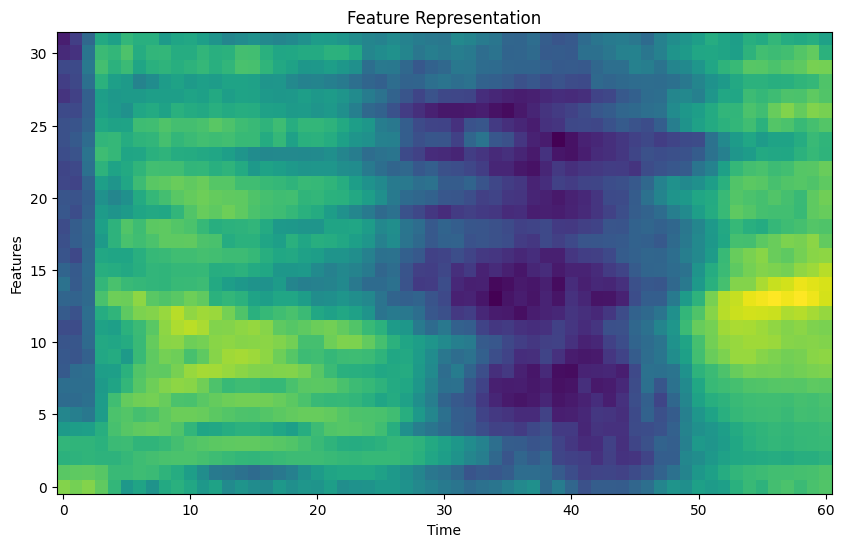

In [16]:
import matplotlib.pyplot as plt

# Testing code to check if your data loaders are working
for i, data in enumerate(train_loader):
    frames, phoneme = data
    print(frames.shape, phoneme.shape)

    # Visualize sample mfcc to inspect and verify everything is correctly done, especially augmentations
    plt.figure(figsize=(10, 6))
    plt.imshow(frames[0].T, aspect='auto', origin='lower', cmap='viridis')
    plt.xlabel('Time')
    plt.ylabel('Features')
    plt.title('Feature Representation')
    plt.show()

    break

The batch dimensions are correct, so the context window and batching are working as expected. I also visualize a sample feature matrix to check that the input looks reasonable after augmentation.

In [17]:
# Testing code to check if your validation data loaders are working
all = []
for i, data in enumerate(val_loader):
    frames, phoneme = data
    all.append(phoneme)
    break

# Network Architecture


I use a fully connected neural network for frame-level phoneme classification.

The input contains 61 × 32 = 1952 values, corresponding to a context of 30 frames on either side of the target frame. The input is flattened before being passed through four hidden layers of 2240 units each, followed by an output layer with 40 phoneme classes.

Batch normalization, GELU activations, and dropout are used between the linear layers. Xavier normal initialization is used for the linear layers.

In [18]:
# This architecture uses a larger cylinder-shaped MLP while staying below
# the official 20-million trainable parameter limit.

class Network(nn.Module):
    def __init__(self, input_size, output_size):
        super(Network, self).__init__()

        self.model = nn.Sequential(
            torch.nn.Linear(input_size, 2240),
            torch.nn.BatchNorm1d(2240),
            torch.nn.GELU(),
            torch.nn.Dropout(config['dropout']),

            torch.nn.Linear(2240, 2240),
            torch.nn.BatchNorm1d(2240),
            torch.nn.GELU(),
            torch.nn.Dropout(config['dropout']),

            torch.nn.Linear(2240, 2240),
            torch.nn.BatchNorm1d(2240),
            torch.nn.GELU(),
            torch.nn.Dropout(config['dropout']),

            torch.nn.Linear(2240, 2240),
            torch.nn.BatchNorm1d(2240),
            torch.nn.GELU(),
            torch.nn.Dropout(config['dropout']),

            torch.nn.Linear(2240, output_size)
        )

        if config['weight_initialization'] is not None:
            self.initialize_weights()

    def initialize_weights(self):
        for m in self.modules():
            if isinstance(m, torch.nn.Linear):
                if config["weight_initialization"] == "xavier_normal":
                    torch.nn.init.xavier_normal_(m.weight)
                elif config["weight_initialization"] == "xavier_uniform":
                    torch.nn.init.xavier_uniform_(m.weight)
                elif config["weight_initialization"] == "kaiming_normal":
                    torch.nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                elif config["weight_initialization"] == "kaiming_uniform":
                    torch.nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                elif config["weight_initialization"] == "uniform":
                    torch.nn.init.uniform_(m.weight)
                else:
                    raise ValueError("Invalid weight_initialization value")

                if m.bias is not None:
                    torch.nn.init.zeros_(m.bias)

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        return self.model(x)

### Model Check

I first check the number of trainable parameters and verify that the model produces an output of shape `(batch_size, 40)`.

The model has about 13.46 million trainable parameters, which is below the 20 million parameter limit.

In [19]:
INPUT_SIZE = (2 * config["context"] + 1) * 32
model = Network(INPUT_SIZE, len(train_data.phonemes)).to(device)
trainable_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
assert trainable_parameters < 20_000_000, "Model exceeds the 20M parameter limit."
print("Trainable parameters:", trainable_parameters)

Trainable parameters: 19541800


In [20]:
# Inspect model architecture & parameter count (purely diagnostic — safe to skip if it errors).
# PSC uses the provided environment; do not install packages into it from the notebook.
ON_PSC = os.path.isdir("/jet/home")
try:
    if not ON_PSC:
        !pip install torchsummaryX==1.1.0 --quiet
    from torchsummaryX import summary
    summary(model, frames.to(device))
except Exception:
    try:
        if not ON_PSC:
            !pip install torchsummary --quiet
        from torchsummary import summary
        summary(model, frames[0].to(device).shape)
    except Exception as e:
        print("Skipping model summary (non-critical):", repr(e))

print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


----------------------------------------------------------------------------------------------------
Layer                   Kernel Shape         Output Shape         # Params (K)      # Mult-Adds (M)
0_Linear                [1952, 2240]         [2048, 2240]             4,374.72                 4.37
1_BatchNorm1d                 [2240]         [2048, 2240]                 4.48                 0.00
2_GELU                             -         [2048, 2240]                    -                    -
3_Dropout                          -         [2048, 2240]                    -                    -
4_Linear                [2240, 2240]         [2048, 2240]             5,019.84                 5.02
5_BatchNorm1d                 [2240]         [2048, 2240]                 4.48                 0.00
6_GELU                             -         [2048, 2240]                    -                    -
7_Dropout                          -         [2048, 2240]                    -                    -

# Define Model, Loss Function and Optimizer

Since this is a multi-class classification problem with 40 possible phoneme classes, I use CrossEntropyLoss.

I use AdamW as the optimizer with a learning rate of 0.001 and weight decay regularization. I use a cosine annealing learning-rate scheduler to gradually reduce the learning rate during training.

Since I am training on a T4 GPU, I use mixed-precision training to reduce memory usage and speed up training.

In [21]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config['learning_rate'],
    weight_decay=config['weight_decay']
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=config['epochs']
)
scaler = torch.amp.GradScaler('cuda', enabled=(device == 'cuda'))

# Training and Validation Functions

For each batch, I move the data to the GPU, run the forward pass, calculate the loss, and update the model parameters using backpropagation.

I track both loss and accuracy during training so that I can compare the model's learning progress across epochs.

In [22]:
# CLEAR RAM!!
torch.cuda.empty_cache()
gc.collect()

45

In [24]:
def train(model, dataloader, optimizer, criterion):

    model.train()
    tloss, tacc = 0, 0
    batch_bar   = tqdm(total=len(dataloader), dynamic_ncols=True, leave=False, position=0, desc='Train')

    for i, (frames, phonemes) in enumerate(dataloader):

        ### Initialize Gradients
        optimizer.zero_grad()

        frames      = frames.to(device)
        phonemes    = phonemes.to(device)

        with torch.autocast(device_type=device, dtype=torch.float16):
            ### Forward Propagation
            logits  = model(frames)

            ### Loss Calculation
            loss    = criterion(logits, phonemes)

        ### Backward Propagation
        scaler.scale(loss).backward()

        ### Gradient Descent
        scaler.step(optimizer)
        scaler.update()

        tloss   += loss.item()
        tacc    += torch.sum(torch.argmax(logits, dim= 1) == phonemes).item()/logits.shape[0]

        batch_bar.set_postfix(loss="{:.04f}".format(float(tloss / (i + 1))),
                              acc="{:.04f}%".format(float(tacc*100 / (i + 1))))
        batch_bar.update()

        ### Release memory
        del frames, phonemes, logits
        torch.cuda.empty_cache()


    batch_bar.close()
    tloss   /= len(dataloader)
    tacc    /= len(dataloader)


    return tloss, tacc

In [25]:
import os

CHECKPOINT_DIR = "/kaggle/input/datasets/bhuvanakanakam/batchnorm2240"

print(os.listdir(CHECKPOINT_DIR))

['best_model.pth']


In [36]:
CHECKPOINT_PATH = "/kaggle/input/datasets/bhuvanakanakam/batchnorm2240/best_model.pth"

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=True
)

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

print("Checkpoint loaded!")
print("Best epoch:", checkpoint["epoch"] + 1)
print("Best validation accuracy:", checkpoint["valid_acc"] * 100)

Checkpoint loaded!
Best epoch: 30
Best validation accuracy: 86.98845168449522


## Validation

During validation, I only perform the forward pass and calculate the loss and accuracy. I do not update the model parameters because the validation data is used only to measure how well the trained model generalizes.

In [37]:
def eval(model, dataloader):

    model.eval() # set model in evaluation mode
    vloss, vacc = 0, 0 # Monitoring loss and accuracy
    batch_bar   = tqdm(total=len(dataloader), dynamic_ncols=True, position=0, leave=False, desc='Val')

    for i, (frames, phonemes) in enumerate(dataloader):

        ### Move data to device (ideally GPU)
        frames      = frames.to(device)
        phonemes    = phonemes.to(device)

        # makes sure that there are no gradients computed as we are not training the model now
        with torch.inference_mode():
            ### Forward Propagation
            logits  = model(frames)
            ### Loss Calculation
            loss    = criterion(logits, phonemes)

        vloss   += loss.item()
        vacc    += torch.sum(torch.argmax(logits, dim= 1) == phonemes).item()/logits.shape[0]

        # Do you think we need loss.backward() and optimizer.step() here?

        batch_bar.set_postfix(loss="{:.04f}".format(float(vloss / (i + 1))),
                              acc="{:.04f}%".format(float(vacc*100 / (i + 1))))
        batch_bar.update()

        ### Release memory
        del frames, phonemes, logits
        torch.cuda.empty_cache()

    batch_bar.close()
    vloss   /= len(dataloader)
    vacc    /= len(dataloader)

    return vloss, vacc

# Weights and Biases Setup

I use Weights & Biases (W&B) to track my experiments during training. It allows me to monitor metrics such as training loss, validation loss, training accuracy, validation accuracy, and learning rate across epochs.

I will also use W&B to keep track of different experiments and compare model configurations when tuning the hyperparameters.

In [29]:
# W&B is used for experiment logging and the final Gradescope code submission.
# Keep API keys out of notebook source by using an environment variable or hidden prompt.
import getpass
import os

WANDB_API_KEY = os.environ.get("WANDB_API_KEY", "").strip()
if not WANDB_API_KEY:
    WANDB_API_KEY = getpass.getpass("Weights & Biases API key: ").strip()

WANDB_USERNAME_OR_TEAMNAME = input(
    "W&B username/team entity (leave blank to use your default entity): "
).strip()
WANDB_PROJECT = "hw1p2"

wandb.login(key=WANDB_API_KEY)
if not WANDB_USERNAME_OR_TEAMNAME:
    WANDB_USERNAME_OR_TEAMNAME = wandb.Api().default_entity
print(f"W&B runs -> {WANDB_USERNAME_OR_TEAMNAME}/{WANDB_PROJECT}")


Weights & Biases API key:  ········
W&B username/team entity (leave blank to use your default entity):  bkanakam-carnegie-mellon-university


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


W&B runs -> bkanakam-carnegie-mellon-university/hw1p2


I connected the notebook to my W&B project so that the training runs and their results are logged automatically. This will make it easier to compare experiments and identify which configuration performs best.

In [38]:
# Create or resume a W&B run.
RESUME_OLD_RUN = False
WANDB_RUN_ID = ""  # TODO: Fill only when resuming a specific run.

if RESUME_OLD_RUN:
    run = wandb.init(
        name=config["Name"],
        id=WANDB_RUN_ID,
        resume="must",
        entity=WANDB_USERNAME_OR_TEAMNAME,
        project=WANDB_PROJECT,
        config=config,
    )
else:
    run = wandb.init(
        name=config["Name"],
        entity=WANDB_USERNAME_OR_TEAMNAME,
        project=WANDB_PROJECT,
        config=config,
        reinit=True,
    )


In [39]:
### Save your model architecture as a string with str(model)
model_arch  = str(model)

### Save it in a txt file
arch_file   = open("model_arch.txt", "w")
file_write  = arch_file.write(model_arch)
arch_file.close()

### log it in your wandb run with wandb.save()
wandb.save('model_arch.txt')

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


['/kaggle/working/wandb/run-20260919_185640-5wrfraq8/files/model_arch.txt']

### Define functions to save model and load checkpoint

In [40]:
def save_model(model, optimizer, scheduler, metric, epoch, path):
    torch.save({
        'model_state_dict'         : model.state_dict(),
        'optimizer_state_dict'     : optimizer.state_dict(),
        'scheduler_state_dict'     : scheduler.state_dict(),
        metric[0]                  : metric[1],
        'epoch'                    : epoch
    }, path)

    # Upload the same checkpoint to WandB
    wandb.save(path, base_path=os.path.dirname(path))

In [41]:
def load_checkpoint(checkpoint_path, model, optimizer, scheduler):

    # load the checkpoint model
    checkpoint = torch.load(checkpoint_path, map_location=device)

    # Check if module is an instance of DataParallel or normal model and load the state dict appropriately
    if isinstance(model, torch.nn.DataParallel):
        print("Model is an instance of Data Parallel")
        model.module.load_state_dict(checkpoint['model_state_dict'])
    else:
        print("Model is a normal model instance")
        model.load_state_dict(checkpoint['model_state_dict'])

    # Load state dicts of the optimizer and scheduler
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

    # retrieve val accuracy and epoch
    valid_acc = checkpoint['valid_acc']
    epoch = checkpoint['epoch']

    # return val accuracy and epoch
    return valid_acc, epoch

# Experiment

Now, it is time to finally run your ablations! Have fun!

In [ ]:
# # Iterate over number of epochs to train and evaluate your model
# torch.cuda.empty_cache()
# gc.collect()
# wandb.watch(model, log="all")

# best_val_acc = 0.0

# for epoch in range(config['epochs']):

#     print("\nEpoch {}/{}".format(epoch+1, config['epochs']))

#     curr_lr                 = float(optimizer.param_groups[0]['lr'])
#     train_loss, train_acc   = train(model, train_loader, optimizer, criterion)
#     val_loss, val_acc       = eval(model, val_loader)

#     print("\tTrain Acc {:.04f}%\tTrain Loss {:.04f}\t Learning Rate {:.07f}".format(train_acc*100, train_loss, curr_lr))
#     print("\tVal Acc {:.04f}%\tVal Loss {:.04f}".format(val_acc*100, val_loss))

#     ## Log metrics at each epoch in your run
#     # Optionally, you can log at each batch inside train/eval functions
#     # (explore wandb documentation/wandb recitation)
#     wandb.log({'train_acc': train_acc*100, 'train_loss': train_loss,
#                'val_acc': val_acc*100, 'valid_loss': val_loss, 'lr': curr_lr})

#     # If using a scheduler, step the learning rate here, otherwise comment this line
#     # Depending on the scheduler in use, you may or may not need to pass in a metric into the step function, so read the docs well
#     # scheduler.step(val_loss)
#     scheduler.step()

#     ## HIGHLY RECOMMENDED: Save model checkpoint in drive and/or wandb if accuracy is better than your current best accuracy
#     ## This enables you to resume training at anytime, without having to start from scratch.
#     ## Refer to Recitation 0.24 to learn how to implement this: https://www.youtube.com/watch?v=-TCH0DbUEKM&list=PLp-0K3kfddPw2D5CeA09lsx_oNy9E

#     if val_acc > best_val_acc:
#         best_val_acc = val_acc

#         save_model(
#             model,
#             optimizer,
#             scheduler,
#             ("valid_acc", val_acc),
#             epoch,
#             "best_model.pth"
#         )

#         print("Saved best model!")

In [49]:
valid_acc, epoch = load_checkpoint(
    "/kaggle/input/datasets/bhuvanakanakam/batchnorm2240/best_model.pth",
    model,
    optimizer,
    scheduler
)

print(f"Loaded best checkpoint from epoch {epoch + 1}")
print(f"Best validation accuracy: {valid_acc * 100:.4f}%")

Model is a normal model instance
Loaded best checkpoint from epoch 30
Best validation accuracy: 86.9885%


### Initial Training Results

After the first epoch, the model reached 70.08% training accuracy and 76.53% validation accuracy. The validation loss was 0.7276.

The validation accuracy being higher than the training accuracy is reasonable here because I apply data augmentation during training, while validation is evaluated without augmentation. The model has already learned useful patterns after the first epoch, so I will continue training and use the validation accuracy to track whether the model keeps improving.

# Testing and submission to Kaggle

Before we get to the following code, make sure to see the format of submission given in *sample_submission.csv*. Once you have done so, it is time to fill the following function to complete your inference on test data. Refer the eval function from previous cells to get an idea of how to go about completing this function.

In [50]:
def test(model, test_loader):
    ### What you call for model to perform inference?
    model.eval()

    ### List to store predicted phonemes of test data
    test_predictions = []

    ### Which mode do you need to avoid gradients?
    with torch.inference_mode():

        for i, mfccs in enumerate(tqdm(test_loader)):

            mfccs   = mfccs.to(device)

            logits  = model(mfccs)

            ### Get most likely predicted phoneme with argmax
            predicted_phonemes = torch.argmax(logits, dim=1)

            ### How do you store predicted_phonemes with test_predictions? HINT: look at the eval() function from earlier
            # Remember the phonemes were converted from strings to their corresponding integer indices earlier, and the results of the argmax is a list of the integer indices of the predicted phonemes.
            # So how do you get and store the actual predicted phonemes (strings NOT integers)
            # TODO: Convert predicted_phonemes (integer indices from argmax) back to phoneme strings and append to test_predictions
            test_predictions.extend(
                [PHONEMES[index] for index in predicted_phonemes.cpu().tolist()]
            )

    ## SANITY CHECK
    sample_predictions = test_predictions[:10]
    if not isinstance(sample_predictions[0], str):
        print(f"❌ ERROR: Predictions should be phoneme STRINGS, not {type(sample_predictions[0]).__name__}!")
        print(f"   You need to convert integer indices to their corresponding phoneme strings")
        print(f"   Hint: Look at the eval() function to get the idea")

    # Print a preview of predictions for manual inspection
    print("\nSample predictions:", sample_predictions)
    print("\nPredictions Generated successfully!")

    return test_predictions

## Generate Test Predictions

Once I have the best trained model, I use it to predict the phoneme for every frame in the test set.

The predictions are converted back from integer class indices to phoneme strings. I then save them in `submission.csv` with the required `ID,TARGET` format and 1-based frame IDs.

In [51]:
predictions = test(model, test_loader)

  0%|          | 0/862 [00:00<?, ?it/s]


Sample predictions: ['[SIL]', '[SIL]', '[SIL]', '[SIL]', '[SIL]', '[SIL]', '[SIL]', '[SIL]', '[SIL]', '[SIL]']

Predictions Generated successfully!


In [52]:
with open("./submission.csv", "w+") as f:
    f.write("ID,TARGET\n")
    for i in range(len(predictions)):
        f.write("{},{}\n".format(i + 1, predictions[i]))

    print("submission.csv file created successfully!")

submission.csv file created successfully!


In [53]:
import pandas as pd

submission = pd.read_csv("./submission.csv")

print("Shape:", submission.shape)
print("\nFirst 5 rows:")
print(submission.head())

print("\nLast 5 rows:")
print(submission.tail())

print("\nNumber of predictions:", len(submission))
print("Expected predictions:", len(test_data))

print("\nUnique phonemes predicted:", submission["TARGET"].nunique())
print("Missing predictions:", submission["TARGET"].isna().sum())

Shape: (1763971, 2)

First 5 rows:
   ID TARGET
0   1  [SIL]
1   2  [SIL]
2   3  [SIL]
3   4  [SIL]
4   5  [SIL]

Last 5 rows:
              ID TARGET
1763966  1763967  [SIL]
1763967  1763968  [SIL]
1763968  1763969  [SIL]
1763969  1763970  [SIL]
1763970  1763971  [SIL]

Number of predictions: 1763971
Expected predictions: 1763971

Unique phonemes predicted: 40
Missing predictions: 0


In [54]:
import os

print(os.path.abspath("./submission.csv"))

/kaggle/working/submission.csv


In [55]:
### Finish your wandb run
run.finish()

# Submit to kaggle competition using kaggle API

In [ ]:
# Set this to True only when you intentionally want to submit to Kaggle.
SUBMIT_TO_KAGGLE = False
USE_SLACK_COMPETITION = False

if SUBMIT_TO_KAGGLE:
    target_competition = SLACK_COMPETITION if USE_SLACK_COMPETITION else COMPETITION
    if target_competition.startswith("<"):
        raise RuntimeError("The selected F26 Kaggle competition slug has not been inserted yet.")
    api.competition_submit(
        file_name="submission.csv",
        message="HW1P2 submission",
        competition=target_competition,
    )
    print(f"Submitted submission.csv to {target_competition}")
else:
    print("Kaggle submission skipped. Set SUBMIT_TO_KAGGLE = True to submit intentionally.")


## 📦 Gradescope Submission Instructions (Read Carefully)

This section guides you through creating and submitting your **final Gradescope code submission**.
Please follow each step in order. Skipping steps may result in an incomplete or invalid submission.

### ⏰ Important Deadlines

* **Kaggle Final Deadline:** See the course schedule
* **Gradescope Code Submission Deadline:**
  **48 hours after** the Kaggle deadline (or the same day as your Slack Kaggle submission, if applicable)

You must submit **both**:

1. A valid Kaggle submission
2. A complete Gradescope code submission zip

Please assign your **final trained model** to the global variable `MODEL`.

We will use this variable to automatically generate a file named
`model_metadata.json`, which records important information about your model (such as parameter count and architecture).

#### 🔴 Important Requirements

* **`MODEL` must be the exact model used for your best Kaggle submission**
* This step is **required** for grading and audit purposes
* If the model does not match your Kaggle submission, your score may be invalidated

#### 🕒 When to Do This

* Run this cell **only after you have finished training** your final model
* Do **not** retrain or modify the model after assigning it to `MODEL`

In [57]:
MODEL = model  

### Step 2: Complete the README Section

Fill in the `README` variable with a brief description of your work:

* **Model**: Architecture and key design choices
* **Training Strategy**: Optimizer, scheduler, loss, etc.
* **Augmentations**: If used (omit if not)
* **Notebook Execution**: Any instructions needed to run your notebook

This README will be included in your submission zip.

In [ ]:
README = """
- **Model**: A fully connected neural network using a cylinder architecture with hidden layers of size 2240. The model uses BatchNorm, GELU activations, and dropout between the linear layers.
- **Training Strategy**: AdamW optimizer with a learning rate of 0.001 and weight decay of 0.05. Cosine Annealing was used as the learning rate scheduler, with Cross Entropy Loss for training. Xavier normal initialization was used for the weights.
- **Augmentations**: Used both frequency masking and time masking on the log-mel spectrogram features, with frequency mask = 4 and time mask = 8.
- **Notebook Execution**: Run the notebook cells in order to load the dataset, create the model, and generate predictions. For submission, the trained checkpoint can be loaded directly instead of retraining the model.
"""

### Step 3: Provide Required Credentials

Ensure the following variables are correctly set:

* `KAGGLE_USERNAME`
* `KAGGLE_API_KEY`
* `WANDB_API_KEY`
* `WANDB_USERNAME_OR_TEAMNAME`
* `WANDB_PROJECT`

These are used **only** to:

* Fetch your official Kaggle score
* Export your top WandB runs for grading

⚠️ Do **not** share your API keys publicly.

In [58]:
KAGGLE_USERNAME = "bhuvanakanakam"
KAGGLE_API_KEY  = "<REDACTED>"
WANDB_API_KEY   = "<REDACTED>"
WANDB_USERNAME_OR_TEAMNAME = "bkanakam-carnegie-mellon-university"
WANDB_PROJECT              = "hw1p2" 

### Step 4: Set File Paths Correctly

You must provide absolute path to your **final notebook**

### Platform-specific guidance

**Colab**

* Right-click a file in the left file pane → **Copy path**
* Paths typically start with `/content/...`

**Kaggle**

* Download your notebook (`File → Download Notebook`)
* Upload it via **Upload Input → Upload Model**
* Copy paths from the right sidebar (`/kaggle/working/...`)

**PSC / Linux**

* Locate files under `/jet/home/<your_username>/`
* Use `!ls` to confirm paths

Paste the correct path below.

In [ ]:
NOTEBOOK_PATH = ""  # TODO: Paste the absolute path to your completed F26 student notebook.


### Step 5: (Optional) Additional Files

If you have extra files you want to include (e.g., config files, scripts), add their paths to `ADDITIONAL_FILES`, Otherwise, leave this list empty.

In [ ]:
ADDITIONAL_FILES = []

### Step 6: Generate the Final Submission Zip

Before running the submission cell:

* Ensure `ACKNOWLEDGED = True`
* Double-check all paths and credentials
* Confirm your Kaggle submission exists

Then run the cell below.
This should generate a `HW1P2_final_submission.zip` which includes:
* Your notebook
* `model_metadata_*.json`
* README
* WandB run exports
* Kaggle metadata
* Academic integrity acknowledgement

In [ ]:
#### DO NOT MODIFY ####
from submission.submission_config import SubmissionConfig
from submission.backend_config import BackendConfig, HW1P2_BACKEND_CONFIG # HW1P2 backend config
from submission.main import create_submission_zip

create_submission_zip(
    cfg = SubmissionConfig(
        model = MODEL,
        kaggle_username  = KAGGLE_USERNAME,
        kaggle_api_key   = KAGGLE_API_KEY,
        wandb_api_key    = WANDB_API_KEY,
        wandb_entity     = WANDB_USERNAME_OR_TEAMNAME,
        wandb_project    = WANDB_PROJECT,
        acknowledged     = ACKNOWLEDGED,
        readme           = README,
        notebook_path    = NOTEBOOK_PATH,
        additional_files = ADDITIONAL_FILES
    ),
    backend_cfg = HW1P2_BACKEND_CONFIG
)

### Step 7: Upload to Gradescope

1. Download `HW1P2_final_submission.zip`
2. Upload it to **Gradescope**
3. Verify the upload succeeds

⚠️ Submitting an incomplete zip or modifying backend code may result in grading penalties or an Academic Integrity Violation.

---

### ✅ Final Checklist

Before submitting, confirm:

* [ ] Kaggle username is valid
* [ ] `model_metadata_*.json` matches your best run
* [ ] README is complete
* [ ] File paths are correct
* [ ] `ACKNOWLEDGED = True`
* [ ] Final zip downloads successfully